## Testing Methods in the `PARCELLATIONTOOLS` Module

This Jupyter Notebook serves as a platform to rigorously test the various methods included in the Python module `PARCELLATIONTOOLS` . The tests are organized into the following sections for clarity and ease of navigation:

---

### Section 1: Parcellation - Surface and Volume Analysis

* **🔷 1. [`Parcellation`](#parcellation-class)**: Class for analyzing and manipulating brain parcellations
  * 🔸 1.1. [`__init__`](#parcellation-init): Initialize the Parcellation class with a parcellation file or array
  * 🔸 1.2. [`get_space_id`](#parcellation-get_space_id): Get the space identifier for the parcellation.
  * 🔸 1.3. [`set_space_id`](#parcellation-set_space_id):   Set the space identifier for the parcellation.
  * 🔸 1.4. [`get_parcellation_id`](#parcellation-get_parcellation_id): Generate a unique identifier for the parcellation based on its filename.  
  * 🔸 1.5. [`get_info`](#parcellation-get_info): Display and return comprehensive information about the Parcellation object.
  * 🔸 1.6. [`prepare_for_tracking`](#parcellation-prepare_for_tracking): Prepare the parcellation for fibre tracking
  * 🔸 1.7. [`keep_by_name`](#parcellation-keep_by_name): Filter the parcellation by region names
  * 🔸 1.8. [`keep_by_code`](#parcellation-keep_by_code): Filter the parcellation by region codes
  * 🔸 1.9. [`remove_by_code`](#parcellation-remove_by_code): Remove regions by their codes
  * 🔸 1.10. [`remove_by_name`](#parcellation-remove_by_name): Remove regions by their names
  * 🔸 1.11. [`apply_mask`](#parcellation-apply_mask): Apply a mask to the parcellation data
  * 🔸 1.12. [`mask_image`](#parcellation-mask_image): Create a binary mask from regions and apply it to images
  * 🔸 1.13. [`compute_region_adjacency`](#parcellation-compute_region_adjacency): Computes the region adjacency (neighbor) matrix for the parcellation.
  * 🔸 1.14. [`compute_centroids`](#parcellation-compute_centroids): Compute centroids, number of voxels, and volume for each region.
  * 🔸 1.15. [`harmonize`](#parcellation-harmonize): Harmonize parcellation attributes with data contents.
  * 🔸 1.16. [`get_regionwise_timeseries`](#parcellation-get_regionwise_timeseries): Compute region-wise time series.
  * 🔸 1.17. [`surface_extraction`](#parcellation-surface_extraction): Extract regions surfaces using the Marching Cubes algorithm
  * 🔸 1.18. [`adjust_values`](#parcellation-adjust_values): Synchronize index, name, and color attributes with data contents
  * 🔸 1.19. [`group_by_code`](#parcellation-group_by_code): Group regions by their codes
  * 🔸 1.20. [`group_by_name`](#parcellation-group_by_name): Group regions by their names
  * 🔸 1.21. [`rearrange`](#parcellation-rearrange): Rearrange the parcellation codes
  * 🔸 1.22. [`add_parcellation`](#parcellation-add_parcellation): Combine another parcellation with this one
  * 🔸 1.23. [`save_parcellation`](#parcellation-save_parcellation): Save the parcellation to a file
  * 🔸 1.24. [`load_colortable`](#parcellation-load_colortable): Add a lookup table to the parcellation
  * 🔸 1.25. [`sort_index`](#parcellation-sort_index): Sort index, name and color attributes
  * 🔸 1.26. [`export_colortable`](#parcellation-export_colortable): Export the lookup table to a file
  * 🔸 1.27. [`replace_values`](#parcellation-replace_values): Replace parcellation values
  * 🔸 1.28. [`parc_range`](#parcellation-parc_range): Detect the range of labels
  * 🔸 1.29. [`compute_morphometry_table`](#parcellation-compute_morphometry_table): Compute morphometry table for all regions in parcellation
  * 🔸 1.30. [`compute_volume_table`](#parcellation-compute_volume_table): Calculate volumes for each region
  * 🔸 1.31. [`compute_fc_matrix`](#parcellation-compute_fc_matrix): Compute a functional connectivity (FC) matrix from a ROI × time series or 4-D NIfTI file



---

### Section 1: Parcellation - Surface and Volume Analysis

<a id="parcellation-class"></a>
* **🔷 1. [`Parcellation`](#parcellation-class)**: Class for analyzing and manipulating brain parcellations

<a id="parcellation-init"></a>
* 🔸 1.1. **`__init__`**: Initialize the Parcellation class with a parcellation file or array
---


In [ ]:
########################### Testing Parcellation Class ###########################
import clabtoolkit.parcellationtools as cltparc
import clabtoolkit.misctools as cltmisc
import os


fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

print("Test 1: Creating a Parcellation Object from file without color table...")
print("Allowed formats: .nii, .nii.gz, .mgz, .img, .mnc")
print("NOTE: Region names, colors and opacities will be default values.")

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, )
cltmisc.show_object_content(parc, show_methods=False, )
print("-------------------------------")
print(" ")

print("\nTest 2: Loading color table from FreeSurferColorLUT.txt...")
print("NOTE: Region names, colors and opacities will be loaded from the color table.")
############## Loading from a file with color table ##################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)
cltmisc.show_object_content(parc, show_methods=False, )
print("-------------------------------")
print(" ")

print("Test 3: Loading a parcellation from a file and adding a dictionary as color table...")
import clabtoolkit.colorstools as cltcolor
color_table = cltcolor.ColorTableLoader.load_colortable(lut_file)
print(color_table)

df = cltmisc.ExplorerDict(color_table).to_dataframe(exclude_keys=["headerlines"])
print(df)

print("Test 4: Loading a parcellation from a numpy array... ")
print("NOTE: Region names, colors and opacities will be default values.")
print("Creating a random 5x5x5 numpy array with integer values between 0 and 9...")
print("The affine matrix will be set to identity matrix by default and the origin of the volume will be set to the center.")

import numpy as np
data = np.random.randint(0, 10, size=(5, 5, 5))
parc = cltparc.Parcellation(data)
cltmisc.show_object_content(parc, show_methods=False, )
print("-------------------------------")
print(" ")

print("Test 5: Loading a parcellation from a numpy array with custom affine matrix and origin...")
affine = np.array([[2, 0, 0, -5],
                [0, 2, 0, -5],
                [0, 0, 2, -5],
                [0, 0, 0, 1]])
parc = cltparc.Parcellation(data, affine=affine) 
cltmisc.show_object_content(parc, show_methods=False, )
print("-------------------------------")
print(" ")

print("Test 6: Loading a parcellation from a numpy array with custom color table...")
index = np.arange(0, 10)
names = [f"Region_{i}" for i in index]
colors = [(i*25 % 256, i*50 % 256, i*75 % 256) for i in index]
opacities = [1.0 for _ in index]
color_table = {'index': index,
            'name': names,
            'color': colors,
            'opacity': opacities}
parc = cltparc.Parcellation(data, color_table=color_table) 
cltmisc.show_object_content(parc, show_methods=False, )
print("-------------------------------")
print(" ")



<a id="parcellation-get_space_id"></a>
* 🔸 1.2. **`get_space_id`**: Get the space identifier for the parcellation.
---

In [ ]:
########################### Testing get_space_id ###########################
import clabtoolkit.parcellationtools as cltparc
import os
import shutil

fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

print("Test 1: Getting a default space ID for a Parcellation Object from file without color table...")
print("Allowed formats: .nii, .nii.gz, .mgz, .img, .mnc")

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file)
parc.get_space_id()

print("Space ID:", parc.space)
print("-------------------------------")
print(" ")

print("Test 2: Getting space ID for a Parcellation Object from file with specified space ID...")

# Copying the parcellation file to a BIDS-compliant filename
space_id = 'MNI152'
bids_parc_file = os.path.join('/tmp', f'sub-{fs_id}_space-{space_id}_desc-aparcaseg_dseg.mgz')
shutil.copy(parc_file, bids_parc_file)

############## Loading from a file with specified space ID ##################
parc = cltparc.Parcellation(bids_parc_file)

# Removing the temporary file
os.remove(bids_parc_file)

# Set the space ID and retrieve it
print("Space ID:", parc.get_space_id())
print("-------------------------------")

<a id="parcellation-set_space_id"></a>
* 🔸 1.3. **`set_space_id`**: Set the space identifier for the parcellation.
---

In [ ]:
########################### Testing set_space_id ###########################
import clabtoolkit.parcellationtools as cltparc
import os

fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

print("Test 1: Setting a default space ID for a Parcellation Object from file without color table...")
print("Allowed formats: .nii, .nii.gz, .mgz, .img, .mnc")

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file)
parc.set_space_id()
print("Space ID:", parc.space)
print("-------------------------------")
print(" ")


print("Test 2: Setting space ID for a Parcellation Object from file with specified space ID...")
############## Loading from a file with specified space ID ##################
# Set the space ID and print it
parc.set_space_id('MySpaceID')
print("Space ID:", parc.space)
print("-------------------------------")

<a id="parcellation-get_parcellation_id"></a>
* 🔸 1.4. **`get_parcellation_id`**: Generate a unique identifier for the parcellation based on its filename.
---

In [ ]:
########################### Testing get_parcellation_id ###########################
import clabtoolkit.parcellationtools as cltparc
import os
import shutil

fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

print("Test 1: Getting parcellation ID for a Parcellation Object from file without color table...")
print("Allowed formats: .nii, .nii.gz, .mgz, .img, .mnc")

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file)
parc.get_parcellation_id()

print("Parcellation ID:", parc.id)
print("-------------------------------")
print(" ")

print("Test 2: Getting parcellation ID for a Parcellation Object from file with specified space ID...")

# Copying the parcellation file to a BIDS-compliant filename
bids_parc_file = os.path.join('/tmp', f'sub-{fs_id}_space-MNI152_atlas-Lausanne2018_scale-1_desc-test_dseg.mgz')
shutil.copy(parc_file, bids_parc_file)

############## Loading from a file with specified space ID ##################
parc = cltparc.Parcellation(bids_parc_file)

# Removing the temporary file
os.remove(bids_parc_file)

# Get the parcellation ID and print it
print("Parcellation ID:", parc.get_parcellation_id())
print("-------------------------------")


<a id="parcellation-get_info"></a>
* 🔸 1.5. **`get_info`**: Display and return comprehensive information about the Parcellation object
---

In [3]:
########################### Testing get_info ###########################
import clabtoolkit.parcellationtools as cltparc
import os
fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

# Loading the parcellation with color table
print("Test 1: Getting parcellation information for a Parcellation Object and printing the table...")
parc = cltparc.Parcellation(parc_file, color_table=lut_file)
info = parc.get_info()
print(" ")


print("Test 2: Getting parcellation information for a Parcellation Object and looking at the dictionary...")
info = parc.get_info(verbose=False)
print("\nParcellation Information:")
print(f"  ID          : {info['id']}")
print(f"  Space       : {info['space']}")
print(f"  Parcellation : {info['parc_file']}")
print(f"  Dimensions   : {info['dim']}")
print(f"  Voxel size   : {info['voxel_size']}")
print(f"  Voxel volume : {info['voxel_volume']}")
print(f"  Data type    : {info['dtype']}")
print(f"  Affine       :\n{info['affine']}")
print("-------------------------------")
print(" ")


Test 1: Getting parcellation information for a Parcellation Object and printing the table...
╔════════════════════════════════════════════════════════════════╗
║                        PARCELLATION INFO                       ║
╠════════════════════════════════════════════════════════════════╣
║  ID     : aparc+aseg                                           ║
║  Space  : unknown                                              ║
║  File   : /opt/freesurfer/subjects/bert/mri/aparc+aseg.mgz     ║
╠════════════════════════════════════════════════════════════════╣
║  IMAGE PROPERTIES                                              ║
║    Dimensions  :      256 x 256 x 256                          ║
║    Voxel size  :      1.0 x 1.0 x 1.0 mm                       ║
║    Voxel volume:            1.000 mm³                          ║
║    Data type   :                  >i4                          ║
╠════════════════════════════════════════════════════════════════╣
║  COLOR TABLE                      

<a id="parcellation-prepare_for_tracking"></a>
* 🔸 1.6. **`prepare_for_tracking`**: Prepare the parcellation for fiber tracking
---


In [ ]:
########################### Testing prepare_for_tracking ###########################
import clabtoolkit.parcellationtools as cltparc
import os
fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

print("Test 1: TO BE DONE WITH A CHIMERA-LIKE PARCELLATION...")

<a id="parcellation-keep_by_name"></a>
* 🔸 1.7. **`keep_by_name`**: Filter the parcellation by region names
---


In [ ]:
########################### Testing keep_by_name ###########################
import clabtoolkit.parcellationtools as cltparc
import os
fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)  

print("Test 1: Keeping regions by their names...")
print("Original number of regions:", len(parc.name))
regions_to_keep = ['ctx-rh-precentral', 'ctx-lh-precentral', 'ctx-rh-postcentral', 'ctx-lh-postcentral']
parc.keep_by_name(regions_to_keep)
print("Number of regions after keep_by_name:", len(parc.name))
print("Remaining region names:", parc.name)
print("Remaining region codes:", parc.index)
print("-------------------------------")
print(" ")

print("Test 2: Keeping regions by names and rearranging the values to be consecutive...")
print("Original number of regions:", len(parc.name))
regions_to_keep = ['ctx-rh-precentral', 'ctx-lh-precentral', 'ctx-rh-postcentral', 'ctx-lh-postcentral']
parc.keep_by_name(regions_to_keep, rearrange=True)
print("Number of regions after keep_by_name:", len(parc.name))
print("Remaining region names:", parc.name)
print("Remaining region codes:", parc.index)
print("-------------------------------")
print(" ")



<a id="parcellation-keep_by_code"></a>
* 🔸 1.8. **`keep_by_code`**: Filter the parcellation by region codes
---


In [ ]:
########################### Testing keep_by_code ###########################
import clabtoolkit.parcellationtools as cltparc
import os
fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

# Defining the regions to keep.
# Note that the codes can be provided in different formats. 
# It uses the method build_indices() (from misctools module) to parse the input.

# It builds a list of unique, sorted indices from a vector containing integers, tuples, lists,
# NumPy arrays, or strings representing values, ranges, or comma-separated expressions.

# Supports:
#     - Integers: added as-is.
#     - Tuples of 2 integers: expanded into range(start, end+1).
#     - Lists or np.ndarray: flattened and added as integers.
#     - Strings:
#         - "8-10"       → [8, 9, 10]
#         - "11:13"      → [11, 12, 13]
#         - "14:2:22"    → [14, 16, 18, 20, 22]
#         - "5"          → [5]
#         - "1, 2, 3"    → [1, 2, 3]
#         - "1, 2, 4:10, 16-20, 25, 0" → parsed into all segments

# Example usage:
# import numpy as np
# range_vector = [1, (2, 5), [6, 7], np.array([0, 0, 0]), "8-10", "11:13", "14:2:22", "1, 2, 4:10, 16-20, 25, 0"]
# range_vector = cltmisc.build_indices(range_vector)
#
# Ouput:
# range_vector = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 18, 20, 22, 25]

# Codes to keep
regions_to_keep = ['1001:1005']

print("Test 1: Keeping regions by their codes...")
parc = cltparc.Parcellation(parc_file, color_table=lut_file)  

print("Original number of regions:", len(parc.name))
parc.keep_by_code(regions_to_keep)
print("Number of regions after keep_by_code:", len(parc.name))
print("Remaining region names:", parc.name)
print("Remaining region codes:", parc.index)
print("-------------------------------")
print(" ")

print("Test 2: Keeping regions by codes and rearranging the values to be consecutive...")
parc = cltparc.Parcellation(parc_file, color_table=lut_file)  

print("Original number of regions:", len(parc.name))
parc.keep_by_code(regions_to_keep, rearrange=True)
print("Number of regions after keep_by_code:", len(parc.name))
print("Remaining region names:", parc.name)
print("Remaining region codes:", parc.index)
print("-------------------------------")
print(" ")


<a id="parcellation-remove_by_code"></a>
* 🔸 1.9. **`remove_by_code`**: Remove regions by their codes
---


In [ ]:
########################### Testing remove_by_code ###########################
import clabtoolkit.parcellationtools as cltparc
import os
fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

# Defining the regions to keep.
# Note that the codes can be provided in different formats. 
# It uses the method build_indices() (from misctools module) to parse the input.

# It builds a list of unique, sorted indices from a vector containing integers, tuples, lists,
# NumPy arrays, or strings representing values, ranges, or comma-separated expressions.

# Supports:
#     - Integers: added as-is.
#     - Tuples of 2 integers: expanded into range(start, end+1).
#     - Lists or np.ndarray: flattened and added as integers.
#     - Strings:
#         - "8-10"       → [8, 9, 10]
#         - "11:13"      → [11, 12, 13]
#         - "14:2:22"    → [14, 16, 18, 20, 22]
#         - "5"          → [5]
#         - "1, 2, 3"    → [1, 2, 3]
#         - "1, 2, 4:10, 16-20, 25, 0" → parsed into all segments

# Example usage:
# import numpy as np
# range_vector = [1, (2, 5), [6, 7], np.array([0, 0, 0]), "8-10", "11:13", "14:2:22", "1, 2, 4:10, 16-20, 25, 0"]
# range_vector = cltmisc.build_indices(range_vector)
#
# Ouput:
# range_vector = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 18, 20, 22, 25]

# Codes to keep
codes2remove = ['1:1000']

print("Test 1: Removing regions by their codes...")
parc = cltparc.Parcellation(parc_file, color_table=lut_file)  

print("Original number of regions:", len(parc.name))
print("Minimum region code:", min(parc.index))
parc.remove_by_code(codes2remove)
print("Number of regions after remove_by_code:", len(parc.name))
print("Minimum region code after remove_by_code:", min(parc.index))
print("All the regions below 1000 were removed.")
print("-------------------------------")
print(" ")

print("Test 2: Removing regions by codes and rearranging the values to be consecutive...")
parc = cltparc.Parcellation(parc_file, color_table=lut_file)
print("Original number of regions:", len(parc.name))
parc.remove_by_code(codes2remove, rearrange=True)
print("Number of regions after remove_by_code:", len(parc.name))
print("Minimum region code after remove_by_code:", min(parc.index))
print("-------------------------------")    




<a id="parcellation-remove_by_name"></a>
* 🔸 1.10. **`remove_by_name`**: Remove regions by their names
---


In [ ]:
########################### Testing remove_by_name ###########################
import clabtoolkit.parcellationtools as cltparc
import os
fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)  

print("Test 1: Removing all the regions with ctx- on their names...")
print("Original number of regions:", len(parc.name))
regions_to_remove = ['ctx-']
parc.remove_by_name(regions_to_remove)
print("Number of regions after remove_by_name:", len(parc.name))
print("Remaining region names:", parc.name)
print("Remaining region codes:", parc.index)
print("-------------------------------")
print(" ")

parc = cltparc.Parcellation(parc_file, color_table=lut_file)  
print("Test 2: Removing regions by names and rearranging the values to be consecutive...")
print("Original number of regions:", len(parc.name))
regions_to_remove = ['ctx-']
parc.remove_by_name(regions_to_remove, rearrange=True)
print("Number of regions after remove_by_name:", len(parc.name))
print("Remaining region names:", parc.name)
print("Remaining region codes:", parc.index)
print("-------------------------------")
print(" ")



<a id="parcellation-apply_mask"></a>
* 🔸 1.11. **`apply_mask`**: Apply a mask to the parcellation data
---


In [ ]:
########################### Testing apply_mask ###########################
import clabtoolkit.parcellationtools as cltparc
import os
fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
dest_id = 'aparc.a2009s+aseg.mgz'
ribbon_id = 'ribbon.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)  

print("Test 1: Applying a mask to the parcellation data...")
print("Using a Parcellation Object created from the ribbon.mgz file as mask...")
ribbon_file = os.path.join(fs_dir, fs_id, 'mri', f'{ribbon_id}')
mask_parc = cltparc.Parcellation(ribbon_file, color_table=lut_file)

# Keeping only the regions where the ribbon image has values 3 (cortical gray matter)
print("Original number of regions:", len(parc.name))
parc.apply_mask(mask_parc, mask_codes=[3, 42])

print("Number of regions after applying the mask:", len(parc.name))
print("Remaining region names:", parc.name)
print("Remaining region codes:", parc.index)
print("-------------------------------")    
print(" ")






<a id="parcellation-mask_image"></a>
* 🔸 1.12. **`mask_image`**: Create a binary mask from regions and apply it to images
---


In [ ]:
########################### Testing mask_image ###########################
import clabtoolkit.parcellationtools as cltparc
import os
fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
dest_id = 'aparc.a2009s+aseg.mgz'
ribbon_id = 'ribbon.mgz'
t1 = 'T1.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')
t1_file = os.path.join(fs_dir, fs_id, 'mri', f'{t1}')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)

print("Test 1: Masking a T1 image using the parcellation data as mask...")
print("Using the parcellation data to mask the T1 image...")
st_codes =[10, 49] # Thalamus codes according to FreeSurferColorLUT.txt
parc.mask_image(t1_file, "/tmp/Thal-T1.mgz", roi_codes=st_codes)
print("Masked T1 image saved to /tmp/Thal-T1.mgz")
print("-------------------------------")    
print(" ")

print("Test 2: Masking a T1 image using the parcellation data as mask with inverted selection...")
print("Using the parcellation data to mask the T1 image...")
st_codes =[10, 49] # Thalamus codes according to FreeSurferColorLUT.txt
parc.mask_image(t1_file, "/tmp/NonThal-T1.mgz", roi_codes=st_codes, invert=True)
print("Masked T1 image saved to /tmp/NonThal-T1.mgz")
print("-------------------------------")    
print(" ")

print("Test 3: Masking a T1 image using the parcellation data as mask using the ROI names...")
print("Using the parcellation data to mask the T1 image...")
st_names = ['Thalamus'] # Thalamus names according to FreeSurferColorLUT.txt
parc.mask_image(t1_file, "/tmp/ThalNames-T1.mgz", roi_names=st_names)
print("Masked T1 image saved to /tmp/ThalNames-T1.mgz")
print("-------------------------------")    
print(" ")

print("Test 4: Masking a T1 image using the parcellation data as mask with inverted selection using the ROI names...")
print("Using the parcellation data to mask the T1 image...")
st_names = ['Thalamus'] # Thalamus names according to FreeSurferColorLUT.txt
parc.mask_image(t1_file, "/tmp/NonThalNames-T1.mgz", roi_names=st_names, invert=True)
print("Masked T1 image saved to /tmp/NonThalNames-T1.mgz")
print("-------------------------------")    
print(" ")

print("Test 5: Masking a T1 image using the codes and names...")
print("Note: This example will give an error since both codes and names are provided...")
st_codes =[10, 49] # Thalamus codes according to FreeSurferColorLUT.txt
st_names = ['Thalamus'] # Thalamus names according to FreeSurferColorLUT.txt
parc.mask_image(t1_file, "/tmp/ThalCodesNames-T1.mgz", roi_codes=st_codes, roi_names=st_names)



<a id="parcellation-compute_region_adjacency"></a>
* 🔸 1.13. **`compute_region_adjacency`**: Computes the region adjacency (neighbor) matrix for the parcellation.
---

In [ ]:
########################### Testing compute_region_adjacency ###########################
import clabtoolkit.parcellationtools as cltparc
import os
fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)

print('Test 1: Computing region adjacency matrix...')
roi_names = "ctx-"
adj_matrix, source, target = parc.compute_region_adjacency(roi_names=roi_names)

import copy
temp_parc = copy.deepcopy(parc)
temp_parc.keep_by_name([roi_names], rearrange=True)
import clabtoolkit.connectivitytools as cltconn
conn_obj = cltconn.Connectome(matrix=adj_matrix, region_names=temp_parc.name, colors=temp_parc.color)
conn_obj.plot_matrix()



<a id="parcellation-compute_centroids"></a>
* 🔸 1.14. **`compute_centroids`**: Compute centroids, number of voxels, and volume for each region in a 3D image.
---

In [ ]:
########################### Testing compute_centroids ###########################
import clabtoolkit.parcellationtools as cltparc
import os
import pandas as pd

fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)

# Example 1: Compute centroids for specified codes
print('Test 1: Computing centroids for specified codes...')
roi_codes = ["1000:2000"]  # Left and right precentral gyrus
centroids_codes = parc.compute_centroids(roi_codes=roi_codes)
# Print the first 5 rows of the centroids dataframe
print(pd.DataFrame(centroids_codes).head())
print(" ")
print("-------------------------------")
print(" ")

# Example 2: Compute centroids for specified names
print('Test 2: Computing centroids for specified names...')
roi_names = ["ctx-lh-precentral", "ctx-rh-precentral"]  # Left and right precentral gyrus
centroids_names = parc.compute_centroids(roi_names=roi_names)
print(pd.DataFrame(centroids_names).head())
print(" ")
print("-------------------------------")
print(" ")

# Example 3: Compute centroids and export to CSV
print('Test 3: Computing centroids and exporting to CSV...')
roi_names = ["ctx-lh-precentral", "ctx-rh-precentral"]  # Left and right precentral gyrus
centroids_names = parc.compute_centroids(roi_names=roi_names, centroid_table="/tmp/centroids.csv")
print(" ")
print("-------------------------------")    


<a id="parcellation-harmonize"></a>
* 🔸 1.15. **`harmonize`**: Harmonize parcellation attributes with data contents.
---

In [ ]:
########################### Testing harmonize ###########################
import clabtoolkit.parcellationtools as cltparc
import os
import numpy as np

############## Loading from a file ###################################
print('Test 1: Harmonizing parcellation to have attributes with lists of values...')
parc_mat = np.random.randint(0, 5, size=(5, 5, 5))
parc = cltparc.Parcellation(parc_mat)

# Creating the color table with different types of values
col_dict = {
    'index': np.arange(1, 5),
    'name': ['Region_1', 'Region_2', 'Region_3', 'Region_4'],
    'color': [(0, 255, 0), 'red', (255, 255, 0), '#009E73'],
    'opacity': [0.8, 0.6, 0.4, 0.2]
}
parc.index = col_dict['index']
parc.name = col_dict['name']
parc.color = col_dict['color']
parc.opacity = col_dict['opacity']

print("Before harmonization:")
parc.index
print("Type of index attribute:", type(parc.index))
print("Name attribute:", parc.name)
print("Type of name attribute:", type(parc.name))
print("Color attribute:", parc.color)
print("Type of color attribute:", type(parc.color))
print("Opacity attribute:", parc.opacity)
print("Type of opacity attribute:", type(parc.opacity))
print(" ")

parc.harmonize()
print("After harmonization:")
parc.index
print("Type of index attribute:", type(parc.index))
print("Name attribute:", parc.name)
print("Now the name attribute is a list of integer values.")
print("Type of name attribute:", type(parc.name))
print("Color attribute:", parc.color)
print("Type of color attribute:", type(parc.color))
print("The colors have been converted to hexadecimal.")
print("Opacity attribute:", parc.opacity)
print("Type of opacity attribute:", type(parc.opacity))
print(" ")
print("-------------------------------")



<a id="parcellation-get_regionwise_timeseries"></a>
* 🔸 1.16. **`get_regionwise_timeseries`**: Compute region-wise time series.
---

In [1]:
########################### Testing get_regionwise_timeseries ###########################
import clabtoolkit.parcellationtools as cltparc
import clabtoolkit.imagetools as cltimg

import os
import pandas as pd

fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)

# Simulate a time series data
sim_image = '/tmp/simulated_4d_data.nii.gz'
sim_img = cltimg.simulate_image(
    input_image=parc_file,      # Changed from 'input_data'
    simulated_image=sim_image,  # Changed from 'simulated_data'
    n_volumes=20
)

# Example 1: Compute region-wise time series from file and removing the first 3 volumes
print("")
print('Test 1: Computing region-wise time series from file...') 
region_ts = parc.get_regionwise_timeseries(sim_image, method="clabtoolkit", vols_to_delete="1-3")
print("Region-wise time series shape:", region_ts.shape)
print(pd.DataFrame(region_ts).head())
print(" ")
print("-------------------------------")    
# print(" ")

# Example 2: Compute region-wise time series using nilearn
print("")
print('Test 2: Computing region-wise time series from file using nilearn...') 
region_ts_nilearn = parc.get_regionwise_timeseries(sim_image, method="nilearn", vols_to_delete="1-3")
print("Region-wise time series shape:", region_ts_nilearn.shape)
print(pd.DataFrame(region_ts_nilearn).head())
print(" ")
print("-------------------------------")
        

Successfully created simulated image:
  Input shape: (256, 256, 256)
  Output shape: (256, 256, 256, 20)
  Non-zero voxels: 1,242,860
  Distribution: normal
  Saved to: /tmp/simulated_4d_data.nii.gz

Test 1: Computing region-wise time series from file...
Successfully removed 3 volumes from /tmp/simulated_4d_data.nii.gz
Output saved to: /tmp/temp_timeseries_dcdfe936-4c58-48cf-a0b5-18d19efc8907.nii.gz
Volumes removed: [1, 2, 3]
Region-wise time series shape: (110, 17)
         0         1         2         3         4         5         6   \
0 -0.000343  0.002541 -0.002620 -0.000656 -0.000573 -0.001691 -0.002690   
1  0.028999  0.001583  0.000082 -0.025808 -0.006920  0.015768 -0.018790   
2  0.024730  0.256619  0.018367 -0.004045 -0.034973 -0.064042  0.091141   
3 -0.011685 -0.000662  0.005593 -0.017035  0.019039  0.005898 -0.005624   
4 -0.003009  0.001591  0.001841  0.002922 -0.004428 -0.002944 -0.007289   

         7         8         9         10        11        12        13  \
0  

[NiftiLabelsMasker.wrapped] Loading regions from 
'/tmp/temp_parcellation_174566d6-b575-4773-aa6b-16a655cb8ec1.nii.gz'

[NiftiLabelsMasker.wrapped] Finished fit

________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker.filter_and_extract...
filter_and_extract('/tmp/temp_timeseries_922919a0-ea6a-4776-adae-89901f96e580.nii.gz', <nilearn.maskers.nifti_labels_masker._ExtractionFunctor object at 0x7e1117b6cd70>, 
{ 'background_label': 0,
  'clean_args': None,
  'clean_kwargs': {},
  'cmap': 'CMRmap_r',
  'detrend': False,
  'dtype': None,
  'high_pass': None,
  'high_variance_confounds': False,
  'keep_masked_labels': False,
  'labels': None,
  'labels_img': '/tmp/temp_parcellation_174566d6-b575-4773-aa6b-16a655cb8ec1.nii.gz',
  'low_pass': None,
  'lut': '/tmp/temp_parcellation_174566d6-b575-4773-aa6b-16a655cb8ec1_nilearnlut.txt',
  'mask_img': None,
  'reports': True,
  'smoothing_fwhm': None,
  'standardize': 'zscore_sample',
  'standardize_confounds': True,
  'strategy': 'mean',
  't_r': None,
  'target_affine': None,
  'target_shape': None}, confounds=None, sample_mask=None, d

[NiftiLabelsMasker.wrapped] Loading data from '/tmp/temp_timeseries_922919a0-ea6a-4776-adae-89901f96e580.nii.gz'

[NiftiLabelsMasker.wrapped] Extracting region signals

[NiftiLabelsMasker.wrapped] Cleaning extracted signals

______________________________________________filter_and_extract - 19.8s, 0.3min
Region-wise time series shape: (110, 17)
         0         1         2         3         4         5         6   \
0  0.276826  1.745998 -0.883515  0.117142  0.159346 -0.410008 -0.919143   
1  2.178455  0.367469  0.268302 -1.441895 -0.194183  1.304478 -0.978301   
2  0.140861  2.676727  0.071269 -0.173816 -0.512040 -0.829930  0.867110   
3 -1.184024 -0.168407  0.407980 -1.676943  1.646933  0.436091 -0.625542   
4 -0.751179  0.280468  0.336393  0.578798 -1.069406 -0.736678 -1.710980   

         7         8         9         10        11        12        13  \
0  0.457535 -1.084115  0.731904  1.222881  1.386203 -0.771067  1.194105   
1 -0.549675  0.262356  0.546430 -1.258326 -0.828154  0.751016  0.025875   
2 -1.002642  1.682656 -1.135410 -0.476656 -0.525638  0.105896 -0.668221   
3  0.098790 -1.357428 -0.243152  1.562325 -0.360309  1.806815 -0.544392   
4  2.055851 -1.074759 -0.582482  0.242321 -0.143386 

<a id="parcellation-surface_extraction"></a>
* 🔸 1.17. **`surface_extraction`**: Extract regions surfaces using the Marching Cubes algorithm.
---

In [ ]:
########################### Testing surface_extraction ###########################
import clabtoolkit.parcellationtools as cltparc
import os
fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)

# Example 1: Extract a surface mesh for specific codes
print('Test 1: Extracting surface mesh for specific codes and returning a list of the extracted meshes...')
codes_to_extract = [10, 49, 8, 47]  # Example codes (Thalamus and Cerebellum Cortex)
surf_list = parc.surface_extraction(roi_codes=codes_to_extract, merge_surfaces=False)
print("Number of surfaces extracted:", len(surf_list))
# surf_list[0].plot() # Uncomment to plot the first surface
print("-------------------------------")
print(" ")

# Example 2: Extract a surface mesh for specific names.
# This will extract all regions that contain the specified strings in their names.
print('Test 2: Extracting surface mesh for specific names and returning a list of the extracted meshes...')
names_to_extract = ['Thalamus', 'Caudate', 'Pallidum']  # Example names
surf_list = parc.surface_extraction(roi_names= names_to_extract, merge_surfaces=False)
# merged_surf.plot()
print("Number of surfaces extracted:", len(surf_list))
print("-------------------------------")
print(" ")

# Example 3: Extract a surface mesh for all regions and save it to a file
print('Test 3: Extracting surface mesh for specific codes and saving to a file...')
merged_surf = parc.surface_extraction(roi_codes= codes_to_extract, 
                                    out_filename="/tmp/merged_surf.freesurfer", 
                                    overwrite=True)
print(f"Surface mesh saved to /tmp/merged_surf.freesurfer")
print(f"Open the surface mesh in Freeview with the command: freeview -f /tmp/merged_surf.freesurfer",)
print("-------------------------------")
print(" ")

# Example 4: Extract a surface mesh for all regions and save the annotation to a file
print('Test 4: Extracting surface mesh for specific names and saving to a file with annotation...')
names_to_extract = ['Thalamus', 'Caudate', 'Pallidum']  # Example names
merged_surf = parc.surface_extraction(roi_names= names_to_extract,
                                    out_filename="/tmp/merged_surf.freesurfer",
                                    overwrite=True,
                                    save_annotation=True)
print(f"Surface mesh and annotation saved to /tmp/merged_surf.freesurfer and /tmp/merged_surf.annot")
print(f"Open the surface mesh in Freeview with the command: freeview -f /tmp/merged_surf.freesurfer:annotation=/tmp/merged_surf.annot",)
print("-------------------------------")
print(" ")

# Example 5: Extract a surface mesh for all regions, merging them into a single mesh
print('Test 5: Extracting surface mesh for specific codes and merging into a single mesh...')
codes_to_extract = [10, 49, 8, 47]  # Example codes (Thalamus and Cerebellum Cortex)
merged_surf = parc.surface_extraction(roi_codes=codes_to_extract, merge_surfaces=True)
print("Merged surface mesh:")
print(merged_surf)
merged_surf.plot()
print("-------------------------------")
print(" ")

# Example 6: Extract a surface mesh for all regions, merging them into a single mesh with names
print('Test 6: Extracting surface mesh for specific names and merging into a single mesh...')
names_to_extract = ['Thalamus', 'Caudate', 'Pallidum']  # Example names
merged_surf = parc.surface_extraction(roi_names= names_to_extract, merge_surfaces=True)
print("Merged surface mesh:")
print(merged_surf)
merged_surf.plot()
print("-------------------------------")
print(" ")






<a id="parcellation-adjust_values"></a>
* 🔸 1.18. **`adjust_values`**: Synchronize index, name, and color attributes with data contents
---


In [ ]:
############################ Testing adjust_values ###########################
import clabtoolkit.parcellationtools as cltparc
import os
fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)

# Example 1: Adjusting parcellation values to adapt the atributes to the data
print('Test 1: Adjusting parcellation values to adapt the attributes to the data...')
print("Original region codes:", len(parc.index)) 
data = parc.data
# Removing all the regions with value bigger than 1000
data[data > 1000] = 0
parc.data = data
parc.adjust_values()
print("Region codes after adjust_values:", len(parc.index)) 
print("Remaining region codes:", parc.index)
print("-------------------------------")
print(" ")



<a id="parcellation-group_by_code"></a>
* 🔸 1.19. **`group_by_code`**: Group regions by their codes
---


In [ ]:
########################### Testing group_by_code ###########################
import clabtoolkit.parcellationtools as cltparc
import os
import numpy as np
import copy

fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)
tmp_parc = copy.deepcopy(parc)


# Example 1: Grouping regions by specified codes
tmp_parc = copy.deepcopy(parc)  

# Keeping only subcortical regions for this example
names2keep = ['Thalamus', 'Caudate', 'Pallidum', 'Putamen', 'Cerebellum-Cortex', 'Hippocampus', 'Amygdala']
tmp_parc.keep_by_name(names2keep)

print('Test 1: Grouping regions by specified codes. Incomplete group definitions...')
group_dict = {3: {'index': ["11:12", "50-52", 13]},
            4: {'index': [10, 49], 'name': 'Thalamus', 'color': '#33FF57', 'opacity': 0.8},
            5: {'index': [17, 53, 18, 54], 'name': 'LimbicSystem', 'color': '#3357FF', 'opacity': 0.8},
            6: {'index': [8, 47], 'name': 'Cerebellum', 'color': '#F1C40F', 'opacity': 0.8}}

# Performing the grouping
new_data, color_table = tmp_parc.group_by_codes(group_dict)
print("New Ids:", np.unique(new_data))
print("New color table:")
print(color_table)
print("-------------------------------")
print(" ")  

# Example 2: Grouping regions and removing ungrouped regions
print('Test 2: Grouping regions by specified codes and removing ungrouped regions...')
tmp_parc = copy.deepcopy(parc)
group_dict = {1: {'index': [10, 49], 'name': 'Thalamus', 'color': '#33FF57', 'opacity': 0.8},   
                2: {'index': [17, 53, 18, 54], 'name': 'LimbicSystem', 'color': '#3357FF', 'opacity': 0.8},
                    3: {'index': [8, 47], 'name': 'Cerebellum', 'color': '#F1C40F', 'opacity': 0.8}}

new_data, color_table = tmp_parc.group_by_codes(group_dict, keep_ungrouped=False)
print("New Ids:", np.unique(new_data))
print("New color table:")
print(color_table)
print("-------------------------------")
print(" ")


# Example 3: Grouping regions by specified codes
print('Test 3: Grouping regions by specified codes and keeping ungrouped regions...')

tmp_parc = copy.deepcopy(parc)

# Keeping only subcortical regions for this example
names2keep = ['Thalamus', 'Caudate', 'Pallidum', 'Putamen', 'Cerebellum-Cortex', 'Hippocampus', 'Amygdala']
tmp_parc.keep_by_name(names2keep)

group_dict = {1: {'index': [10, 49], 'name': 'Thalamus', 'color': '#33FF57', 'opacity': 0.8},   
                2: {'index': [17, 53, 18, 54], 'name': 'LimbicSystem', 'color': '#3357FF', 'opacity': 0.8},
                    3: {'index': [8, 47], 'name': 'Cerebellum', 'color': '#F1C40F', 'opacity': 0.8}}

new_data, color_table = tmp_parc.group_by_codes(group_dict, keep_ungrouped=True)
print("New Ids:", np.unique(new_data))
print("New color table:")
print(color_table)
print("-------------------------------")
print(" ")




<a id="parcellation-group_by_name"></a>
* 🔸 1.20. **`group_by_name`**: Group regions by their names
---


In [ ]:
########################### Testing group_by_names ###########################
import clabtoolkit.parcellationtools as cltparc
import os
import numpy as np
import copy

fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)

print('Test 1: Grouping regions by specified names...')

# Keeping only subcortical regions for this example
tmp_parc = copy.deepcopy(parc)
names2keep = ['Thalamus', 'Caudate', 'Pallidum', 'Putamen', 'Cerebellum-Cortex', 'Hippocampus', 'Amygdala']
tmp_parc.keep_by_name(names2keep)

group_dict = {
    'subc-lh-basalganglia': {"names": ["Left-Putamen", "Left-Thalamus", "Left-Caudate", "Left-Pallidum"],"color": (255, 0, 0), "opacity": 0.8, "index": 1},
    'subc-rh-basalganglia': {"names": ["Right-Putamen", "Right-Thalamus", "Right-Caudate", "Right-Pallidum"],"color": (0, 255, 0), "opacity": 0.8, "index": 2},
    'cer-mid-cerebellum': {"names": ["Left-Cerebellum-Cortex", "Right-Cerebellum-Cortex"],"color": (0, 0, 255), "opacity": 0.8, "index": 3},
}

new_data, color_table = tmp_parc.group_by_names(group_dict, keep_ungrouped=False)
print("New Ids:", np.unique(parc.data))
print("New color table:")
print(parc.color)
print("-------------------------------")
print(" ")

# Example 2: Grouping regions by specified names and keeping ungrouped regions
print('Test 2: Grouping regions by specified names and keeping ungrouped regions...')
tmp_parc = copy.deepcopy(parc)
group_dict = {
    'subc-lh-basalganglia': {"names": ["Left-Putamen", "Left-Thalamus", "Left-Caudate", "Left-Pallidum"],"color": (255, 0, 0), "opacity": 0.8, "index": 1},
    'subc-rh-basalganglia': {"names": ["Right-Putamen", "Right-Thalamus", "Right-Caudate", "Right-Pallidum"],"color": (0, 255, 0), "opacity": 0.8, "index": 2},
    'cer-mid-cerebellum': {"names": ["Left-Cerebellum-Cortex", "Right-Cerebellum-Cortex"],"color": (0, 0, 255), "opacity": 0.8, "index": 3},
}
new_data, color_table = tmp_parc.group_by_names(group_dict, keep_ungrouped=True)
print("New Ids:", np.unique(new_data))
print("New color table:")
print(color_table)
print("-------------------------------")
print(" ")




<a id="parcellation-rearrange"></a>
* 🔸 1.21. **`rearrange`**: Rearrange the parcellation codes
---


In [ ]:
########################### Testing rearrange ###########################
import clabtoolkit.parcellationtools as cltparc
import os
import copy

fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)

# Example 1: Rearranging parcellation codes to be consecutive
print('Test 1: Rearranging parcellation codes to be consecutive...')
vparc_data = copy.deepcopy(parc)
print(f"Original codes: {vparc_data.index}")
include_ids = ['1001:1035', '2001:2035']  # Keeping only cortical regions

vparc_data.keep_by_code(codes2keep=include_ids)

print(f"Remaining codes after exclusion: {vparc_data.index}")
print(f"Remaining names after exclusion: {vparc_data.name}")
print(f"Remaining colors after exclusion: {vparc_data.color}")
print(" ")

vparc_data.rearrange()
print("After rearrangement to be consecutive:")
print(f"Remaining codes after rearrangement: {vparc_data.index}")
print(f"Remaining names after rearrangement: {vparc_data.name}")
print(f"Remaining colors after rearrangement: {vparc_data.color}")
print("-------------------------------")
print(" ")

# Example 2: Rearranging parcellation codes with an offset
print('Test 2: Rearranging parcellation codes with an offset of 10...')
vparc_data = copy.deepcopy(parc)
print(f"Original codes: {vparc_data.index}")
include_ids = ['1001:1035', '2001:2035']  # Keeping only cortical regions
vparc_data.keep_by_code(codes2keep=include_ids)

vparc_data.rearrange(offset=10)
print(f"Remaining codes after rearrangement: {vparc_data.index}")
print(f"Remaining names after rearrangement: {vparc_data.name}")
print(f"Remaining colors after rearrangement: {vparc_data.color}")
print("-------------------------------")
print(" ")




<a id="parcellation-add_parcellation"></a>
* 🔸 1.22. **`add_parcellation`**: Combine another parcellation with this one
---


In [ ]:
########################### Testing add_parcellation ###########################
import clabtoolkit.parcellationtools as cltparc

import os
import copy

fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)
parc_tmp_ctx_rh = copy.deepcopy(parc)

# Keeping the Right cortical regions 
parc_tmp_ctx_rh.keep_by_name(['ctx-rh-'])

# Keeping the Left Thalamus, Left Caudate, Left Putamen, Left Pallidum
parc_tmp_subc = copy.deepcopy(parc)
parc_tmp_subc.keep_by_code([10, 11, 12, 13])

print('Test 1: Adding two parcellations together...')
print("1. Number of regions before adding parcellation:", len(parc_tmp_ctx_rh.name))

parc_tmp_ctx_rh.add_parcellation(parc_tmp_subc)
print("2. Number of regions after adding two parcellations:", len(parc_tmp_ctx_rh.name))
print("-------------------------------")
print("3. Save the new parcellation to /tmp/combined_parcellation.mgz")
parc_tmp_ctx_rh.save_parcellation('/tmp/combined_parcellation.mgz')
print(" ")







<a id="parcellation-save_parcellation"></a>
* 🔸 1.23. **`save_parcellation`**: Save the parcellation to a file
---


In [ ]:
########################### Testing save_parcellation ###########################
import clabtoolkit.parcellationtools as cltparc
import os

fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)

# Example: Save the parcellation to a new file with no color table
print('Test 1: Saving the parcellation to a new file...')
output_file = '/tmp/saved_parcellation.mgz'
parc.save_parcellation(output_file, force=True) # It saves a color table by default if available
print(f"Parcellation saved to {output_file}")
print("To view it run:")
print(f"freeview -v {output_file}:lut=/tmp/saved_parcellation.lut &")
print("-------------------------------")    
print(" ")

# Example: Save the parcellation to a new file without color table
print('Test 2: Saving the parcellation to a new file without color table...')
output_file_no_ct = '/tmp/saved_parcellation_no_ct.mgz'
parc.save_parcellation(output_file_no_ct, lut_type=None) # It does not save a color table
print(f"Parcellation saved to {output_file_no_ct} without color table")
print("To view it run:")
print(f"freeview -v {output_file_no_ct} &")
print("-------------------------------")

# Example: Save the parcellation to a new file with a specific color table format
print('Test 3: Saving the parcellation to a new file with a specific color table format...')
output_file_nilearn_ct = '/tmp/saved_parcellation_nilearn_ct.mgz'
parc.save_parcellation(output_file_nilearn_ct, lut_type='nilearn') # It saves a Nilearn color table
print(f"Parcellation saved to {output_file_nilearn_ct} with Nilearn color table")
lut_file = '/tmp/saved_parcellation_nilearn_ct.lut'
print("To view it run:")
print(f"freeview -v {output_file_nilearn_ct}:lut={lut_file} &")
print("-------------------------------")
print(" ")

# Example: Save the parcellation to a new file with a custom color table
print('Test 4: Saving the parcellation with a certain filename...')
output_file_custom_ct = '/tmp/saved_parcellation_custom_ct.mgz'
lut_file = '/tmp/custom_lut.txt'
parc.save_parcellation(output_file_custom_ct, lut_file=lut_file) # It saves a custom color table
print(f"Parcellation saved to {output_file_custom_ct} with custom color table")
print("To view it run:")
print(f"freeview -v {output_file_custom_ct}:lut={lut_file} &")
print("-------------------------------")    


<a id="parcellation-load_colortable"></a>
* 🔸 1.24. **`load_colortable`**: Add a lookup table to the parcellation
---


In [ ]:
########################### Testing load_colortable ###########################
import clabtoolkit.parcellationtools as cltparc
import os
fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file)

print('Test 1: Loading color table from a file...')
print("Names of the regions:", parc.name)
parc.load_colortable(lut_file)

print("Names of the regions after loading color table:", parc.name)
                            




<a id="parcellation-sort_index"></a>
* 🔸 1.25. **`sort_index`**: Sort index, name and color attributes
---


In [ ]:
############################## Testing sort_index ###########################
import clabtoolkit.parcellationtools as cltparc
import os
import numpy as np

parc_matrix = np.array([[[0, 2, 0],
                        [1, 0, 3],
                        [0, 0, 0]],
                        [[0, 0, 0],
                        [4, 0, 0],
                        [0, 5, 0]],
                        [[0, 0, 0],
                        [0, 0, 0],
                        [6, 0, 0]]])    

parc = cltparc.Parcellation(parc_matrix)
index = [3, 1, 5, 2, 6, 4]
name = ['Region_3', 'Region_1', 'Region_5', 'Region_2', 'Region_6', 'Region_4']
parc.index = index
parc.name = name

print('Test 1: Sorting parcellation...')
print("Original indices:", parc.index)
print("Original names:", parc.name)
parc.sort_index()
print("")
print("Sorted indices:", parc.index)
print("Sorted names:", parc.name)





<a id="parcellation-export_colortable"></a>
* 🔸 1.26. **`export_colortable`**: Export the lookup table to a file
---


In [ ]:
############################ Testing export_colortable ###########################
import clabtoolkit.parcellationtools as cltparc
import os
fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)

print('Test 1: Exporting color table to a file...')
output_lut_file = '/tmp/exported_colortable.txt'
parc.export_colortable(output_lut_file)
print(f"Color table exported to {output_lut_file}")
print("-------------------------------")
print(" ")

# Example: Exporting color table in Nilearn format
print('Test 2: Exporting color table to a file in Nilearn format...')
output_lut_file_nilearn = '/tmp/exported_colortable_nilearn.txt'
parc.export_colortable(output_lut_file_nilearn, lut_type='nilearn')
print(f"Color table exported to {output_lut_file_nilearn} in Nilearn format")   
print("-------------------------------")
print(" ")

# Example 3: Exporting color table in FSL format
print('Test 3: Exporting color table to a file in FSL format...')
output_lut_file_fsl = '/tmp/exported_colortable_fsl.txt'
parc.export_colortable(output_lut_file_fsl, lut_type='fsl')
print(f"Color table exported to {output_lut_file_fsl} in FSL format")
print("-------------------------------")
print(" ")



<a id="parcellation-replace_values"></a>
* 🔸 1.27. **`replace_values`**: Replace parcellation values
---


In [ ]:
############################## Testing replace_values ###########################
import clabtoolkit.parcellationtools as cltparc
import os
fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)

# Test 1: Replacing region codes
print('Test 1: Replacing region codes...')
print("Original region codes:", parc.index)
replace_dict = {10: 100010, 49: 100049, 11: 100011}  # Example replacements
parc.replace_values(replace_dict)
print("Updated region codes:", parc.index)
print("-------------------------------")
print(" ")




<a id="parcellation-parc_range"></a>
* 🔸 1.28. **`parc_range`**: Detect the range of labels
---


In [ ]:
############################## Testing parc_range ###########################
import clabtoolkit.parcellationtools as cltparc
import os
fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)

# Test 1: Getting parcellation range
print('Test 1: Getting parcellation range...')
min_code, max_code = parc.parc_range()
print(f"Parcellation range: Min code = {min_code}, Max code = {max_code}")
print("-------------------------------")
print(" ")

# Test 2: Getting parcellation range after modifying data
print('Test 2: Getting parcellation range after modifying data...')
parc.remove_by_name(['ctx-lh-', 'ctx-rh-'])  # Remove cortical regions
min_code, max_code = parc.parc_range()
print(f"Parcellation range after removing cortical regions: Min code = {min_code}, Max code = {max_code}")
print("-------------------------------")
print(" ")



<a id="parcellation-compute_morphometry_table"></a>
* 🔸 1.29. **`compute_morphometry_table`**: Compute morphometry table for all regions in parcellation
---


In [ ]:
############################## Testing compute_morphometry_table ###########################
import clabtoolkit.parcellationtools as cltparc
import os
import clabtoolkit.imagetools as cltmimg

fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)
print('Generating simulated images for morphometry table tests...')
# Simulate two images with different metrics
simulated_image = '/tmp/simulated_data.nii.gz'
cltmimg.simulate_image(input_image=parc_file, simulated_image=simulated_image, n_volumes=1)
print(" ")

simulated_image2 = '/tmp/simulated_data2.nii.gz'
cltmimg.simulate_image(input_image=parc_file, simulated_image=simulated_image2, n_volumes=1)
print(" ")

# Test 1: Compute morphometry table for specified maps
print('Test 1: Computing morphometry table for specified maps...')
morphometry_table = parc.compute_morphometry_table( map_files=[simulated_image,simulated_image2], units=["m", "s"], map_ids=["distance", "time"]
                                )
print(morphometry_table.head())
print("-------------------------------")    
print(" ")

# Test 2:  Compute morphometry table for all regions in parcellation and save to CSV
print('Test 2: Computing morphometry table for all regions and saving to CSV...')
morphometry_table = parc.compute_morphometry_table( map_files=[simulated_image,simulated_image2], units=["m", "s"], map_ids=["distance", "time"],       
                                output_table="/tmp/morphometry_table.csv"
                                )
print("Morphometry table saved to /tmp/morphometry_table.csv")
print("-------------------------------")
print(" ")

# Test 3: Compute morphometry table for specified region names
print('Test 3: Computing morphometry table for specified region names...')
region_names = ['ctx-lh-precentral', 'ctx-rh-precentral']
morphometry_table = parc.compute_morphometry_table( map_files=[simulated_image,simulated_image2], 
                                                    units=["m", "s"], map_ids=["distance", "time"],
                                                    include_by_name=region_names
                                )
print(morphometry_table.head())
print("-------------------------------")    
print(" ")  

Generating simulated images for morphometry table tests...
Successfully created simulated image:
  Input shape: (256, 256, 256)
  Output shape: (256, 256, 256)
  Non-zero voxels: 1,242,860
  Distribution: normal
  Saved to: /tmp/simulated_data.nii.gz
 
Successfully created simulated image:
  Input shape: (256, 256, 256)
  Output shape: (256, 256, 256)
  Non-zero voxels: 1,242,860
  Distribution: normal
  Saved to: /tmp/simulated_data2.nii.gz
 
Test 1: Computing morphometry table for specified maps...


Output()

         Source  Metric Units  \
0  parcellation  volume   cm3   
1  parcellation  volume   cm3   
2  parcellation  volume   cm3   
3  parcellation  volume   cm3   
4  parcellation  volume   cm3   

                                         MetricFile Supraregion  Hemisphere  \
0  /opt/freesurfer/subjects/bert/mri/aparc+aseg.mgz       brain       brain   
1  /opt/freesurfer/subjects/bert/mri/aparc+aseg.mgz        Left    Cerebral   
2  /opt/freesurfer/subjects/bert/mri/aparc+aseg.mgz        Left     Lateral   
3  /opt/freesurfer/subjects/bert/mri/aparc+aseg.mgz        Left         Inf   
4  /opt/freesurfer/subjects/bert/mri/aparc+aseg.mgz        Left  Cerebellum   

                         Region     Value  Median  Std  Min  Max  
0        brain-brain-wholebrain  1242.860     NaN  NaN  NaN  NaN  
1    Left-Cerebral-White-Matter   246.545     NaN  NaN  NaN  NaN  
2        Left-Lateral-Ventricle     6.980     NaN  NaN  NaN  NaN  
3             Left-Inf-Lat-Vent     0.206     NaN  NaN  Na

<a id="parcellation-compute_volume_table"></a>
* 🔸 1.30. **`compute_volume_table`**: Calculate volumes for each region
---

In [ ]:
############################## Testing compute_volume_table ###########################
import clabtoolkit.parcellationtools as cltparc
import os
import clabtoolkit.imagetools as cltmimg

fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)

# Test 1: Compute volume table for all regions
print('Test 1: Computing volume table for all regions...')
volume_table,_ = parc.compute_volume_table()
print(volume_table.head())
print("-------------------------------")    
print(" ")

# Test 2: Compute volume table for specified region names and save to CSV
print('Test 2: Computing volume table for the left cortical regions ...')
region_names = ['ctx-lh-']
volume_table,_ = parc.compute_volume_table( include_by_name=region_names,
                                        )
print("Volume table saved to /tmp/volume_table.csv")
print("-------------------------------")    
print(" ")

# Test 3: Compute volume table for specified region codes
print('Test 3: Computing volume table for specified region codes ...')
region_codes = [10, 49, 11, 50]
volume_table,_ = parc.compute_volume_table( include_by_code=region_codes,
                                        output_table="/tmp/volume_table_codes.csv"
                                        )
print("Volume table saved to /tmp/volume_table_codes.csv")
print("-------------------------------")    
print(" ")

<a id="parcellation-compute_fc_matrix"></a>
* 🔸 1.31. **`compute_fc_matrix`**: Compute a functional connectivity (FC) matrix from a ROI × time series or 4-D NIfTI file
---

Successfully created simulated image:
  Input shape: (256, 256, 256)
  Output shape: (256, 256, 256, 20)
  Non-zero voxels: 1,242,860
  Distribution: normal
  Saved to: /tmp/simulated_4d_data.nii.gz

Test 1: Computing the functional connectivity matrix using a region-wise time series...
Simulated 4D image shape: (256, 256, 256, 20)
Computing region-wise time series using clabtoolkit method and removing the first 3 volumes...
Only the cortical regions will be included in the time series extraction...
Successfully removed 3 volumes from /tmp/simulated_4d_data.nii.gz
Output saved to: /tmp/temp_timeseries_a1bd9f6b-df7a-4e77-a681-fbda9bfa0a12.nii.gz
Volumes removed: [1, 2, 3]


[NiftiLabelsMasker.wrapped] Loading regions from 
'/tmp/temp_parcellation_75c5c958-659f-4d42-a4b1-246a03a428e1.nii.gz'

[NiftiLabelsMasker.wrapped] Finished fit

________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker.filter_and_extract...
filter_and_extract('/tmp/temp_timeseries_a1bd9f6b-df7a-4e77-a681-fbda9bfa0a12.nii.gz', <nilearn.maskers.nifti_labels_masker._ExtractionFunctor object at 0x70d983979f70>, 
{ 'background_label': 0,
  'clean_args': None,
  'clean_kwargs': {},
  'cmap': 'CMRmap_r',
  'detrend': False,
  'dtype': None,
  'high_pass': None,
  'high_variance_confounds': False,
  'keep_masked_labels': False,
  'labels': None,
  'labels_img': '/tmp/temp_parcellation_75c5c958-659f-4d42-a4b1-246a03a428e1.nii.gz',
  'low_pass': None,
  'lut': '/tmp/temp_parcellation_75c5c958-659f-4d42-a4b1-246a03a428e1_nilearnlut.txt',
  'mask_img': None,
  'reports': True,
  'smoothing_fwhm': None,
  'standardize': 'zscore_sample',
  'standardize_confounds': True,
  'strategy': 'mean',
  't_r': None,
  'target_affine': None,
  'target_shape': None}, confounds=None, sample_mask=None, d

[NiftiLabelsMasker.wrapped] Loading data from '/tmp/temp_timeseries_a1bd9f6b-df7a-4e77-a681-fbda9bfa0a12.nii.gz'

[NiftiLabelsMasker.wrapped] Extracting region signals

[NiftiLabelsMasker.wrapped] Cleaning extracted signals

______________________________________________filter_and_extract - 21.3s, 0.4min


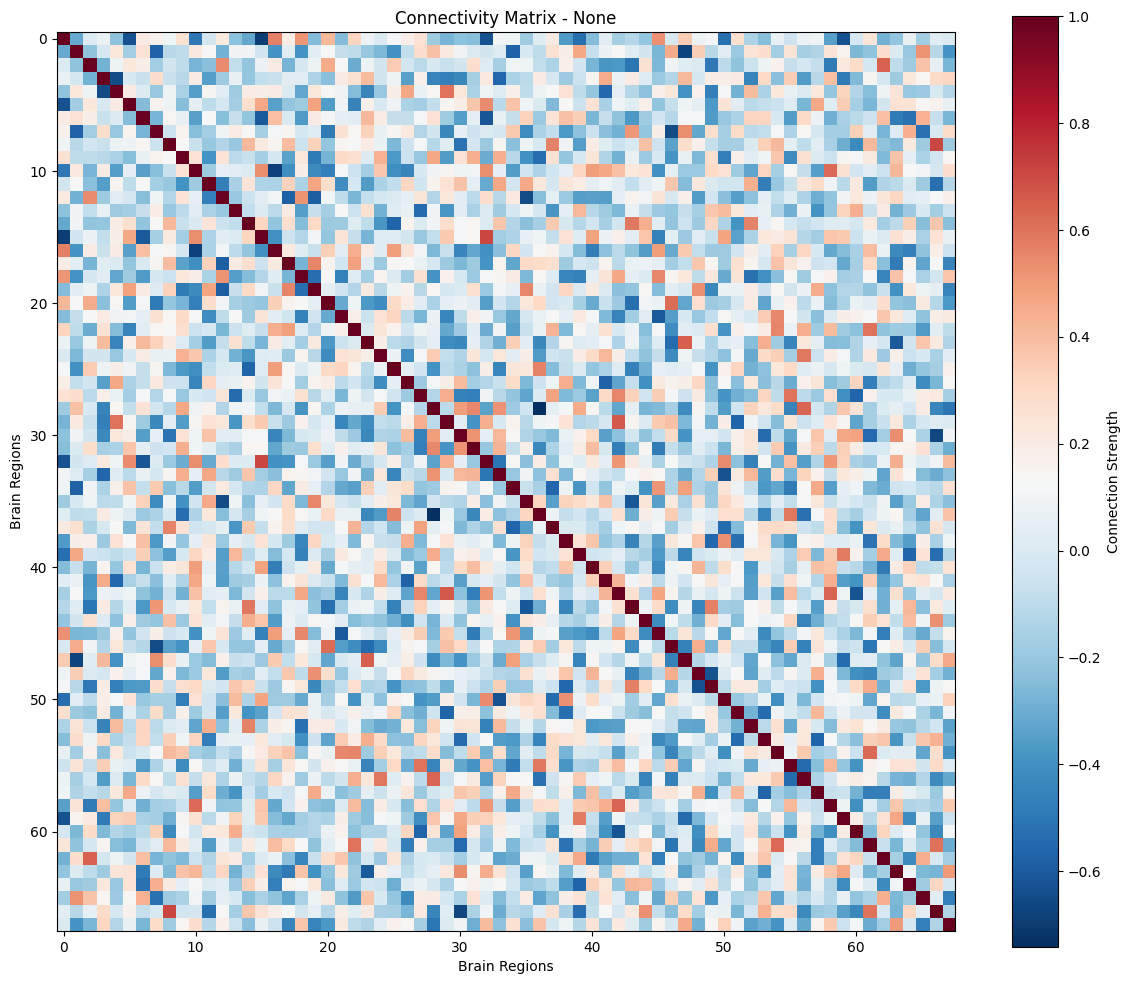

-------------------------------


In [ ]:
########################### Testing get_regionwise_timeseries ###########################
import clabtoolkit.parcellationtools as cltparc
import clabtoolkit.imagetools as cltimg

import os
import pandas as pd

fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)

# Simulate a time series data
sim_image = '/tmp/simulated_4d_data.nii.gz'
sim_img = cltimg.simulate_image(
    input_image=parc_file,      # Changed from 'input_data'
    simulated_image=sim_image,  # Changed from 'simulated_data'
    n_volumes=20
)

# Example 1: Compute region-wise time series from file and removing the first 3 volumes
print("")
print('Test 1: Computing the functional connectivity matrix using a region-wise time series...')
print("Simulated 4D image shape:", sim_img.shape)
print("Computing region-wise time series using nilearn method and removing the first 3 volumes...")
print("Only the cortical regions will be included in the time series extraction...") 

conn_mat = parc.compute_fc_matrix(sim_image, vols_to_delete="1-3", roi_names="ctx")
conn_mat.plot_matrix()

print("-------------------------------")   